# AI-Based Network Intrusion Detection System — V1

**Binary flow-level intrusion detection using CICIDS2017**



## 1. Imports and configuration

In [26]:
import os
import re
import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
import joblib

RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)

DATA_DIR = Path(os.environ.get("CICIDS_DATA_DIR", "data/MachineLearningCVE"))
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
]

TEST_FILES = [
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

LABEL_COL = "Label"
print("Dataset directory:", DATA_DIR.resolve())

Dataset directory: /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/data/MachineLearningCVE


## 2. Load CICIDS2017

Monday–Thursday form the development data. Friday is loaded for inspection, but it is kept closed to the model until the unseen-family evaluation is complete.

In [27]:
def normalise_label(value):
    s = re.sub(r"[^\x20-\x7E]+", "-", str(value))
    s = re.sub(r"\s*-\s*", " - ", s)
    return re.sub(r"\s+", " ", s).strip()

def load_cicids_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing dataset file: {path}")
    df = pd.read_csv(path, encoding="latin-1", low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]
    if LABEL_COL not in df.columns:
        raise ValueError(f"{path.name}: '{LABEL_COL}' column not found.")
    df[LABEL_COL] = df[LABEL_COL].map(normalise_label)
    for col in df.columns:
        if col != LABEL_COL:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df["SourceFile"] = path.name
    return df

def load_group(files):
    frames = []
    for filename in files:
        print("Loading:", filename)
        frames.append(load_cicids_csv(DATA_DIR / filename))
    return pd.concat(frames, ignore_index=True)

dev_raw = load_group(DEV_FILES)
friday_raw = load_group(TEST_FILES)

print("\nDevelopment shape:", dev_raw.shape)
print("Friday shape:", friday_raw.shape)

Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Development shape: (2127498, 80)
Friday shape: (703245, 80)


## 3. Dataset audit

In [28]:
def audit(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nLabels:")
    print(df[LABEL_COL].value_counts(dropna=False))

    feature_cols = [c for c in df.columns if c not in [LABEL_COL, "SourceFile"]]
    X = df[feature_cols]
    print("\nData quality:")
    print("NaN values:", f"{int(X.isna().sum().sum()):,}")
    print("Infinite values:", f"{int(np.isinf(X.to_numpy()).sum()):,}")
    print("Duplicate column names:", df.columns[df.columns.duplicated()].tolist())
    print("Exact duplicate rows:", f"{int(df.duplicated().sum()):,}")

audit(dev_raw, "Monday–Thursday development")
audit(friday_raw, "Friday held-out data")


===== Monday–Thursday development =====
Shape: (2127498, 80)

Labels:
Label
BENIGN                        1858775
DoS Hulk                       231073
DoS GoldenEye                   10293
FTP - Patator                    7938
SSH - Patator                    5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Data quality:
NaN values: 1,311
Infinite values: 3,369
Duplicate column names: []
Exact duplicate rows: 174,605

===== Friday held-out data =====
Shape: (703245, 80)

Labels:
Label
BENIGN      414322
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64

Data quality:
NaN values: 47
Infinite values: 1,007
Duplicate column names: []
Exact duplicate rows: 81,874


## 4. Create the binary target and clean structural issues

`BENIGN = 0` and every attack label becomes `1`. The original attack family is preserved for analysis.

Repeated columns and malformed rows are removed. Exact duplicate rows are removed only from development data; Friday remains untouched.

In [29]:
def prepare_dataframe(df, remove_duplicate_rows=False):
    out = df.copy()
    out.columns = [str(c).strip() for c in out.columns]
    out = out.loc[:, ~out.columns.duplicated()].copy()

    repeated = [
        c for c in out.columns
        if c not in [LABEL_COL, "SourceFile"]
        and c.endswith(".1")
        and c[:-2] in out.columns
    ]
    if repeated:
        out = out.drop(columns=repeated)

    out[LABEL_COL] = out[LABEL_COL].where(out[LABEL_COL].notna(), "")
    out[LABEL_COL] = out[LABEL_COL].astype(str).str.strip()
    out["AttackType"] = out[LABEL_COL].replace({"BENIGN": "BENIGN"})
    out["y"] = (out[LABEL_COL] != "BENIGN").astype(np.int8)

    feature_cols = [c for c in out.columns if c not in [LABEL_COL, "AttackType", "y", "SourceFile"]]
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=feature_cols, how="all")
    out = out[out[LABEL_COL].str.len() > 0].copy()

    if remove_duplicate_rows:
        before = len(out)
        out = out.drop_duplicates().reset_index(drop=True)
        print(f"Removed {before - len(out):,} exact duplicate development rows.")
    else:
        out = out.reset_index(drop=True)

    return out

dev = prepare_dataframe(dev_raw, remove_duplicate_rows=True)
friday = prepare_dataframe(friday_raw, remove_duplicate_rows=False)

print("Development after cleaning:", dev.shape)
print("Friday after cleaning:", friday.shape)

del dev_raw, friday_raw
gc.collect()

Removed 174,605 exact duplicate development rows.
Development after cleaning: (1952893, 81)
Friday after cleaning: (703245, 81)


24411

## 5. Data analysis — class and attack distribution



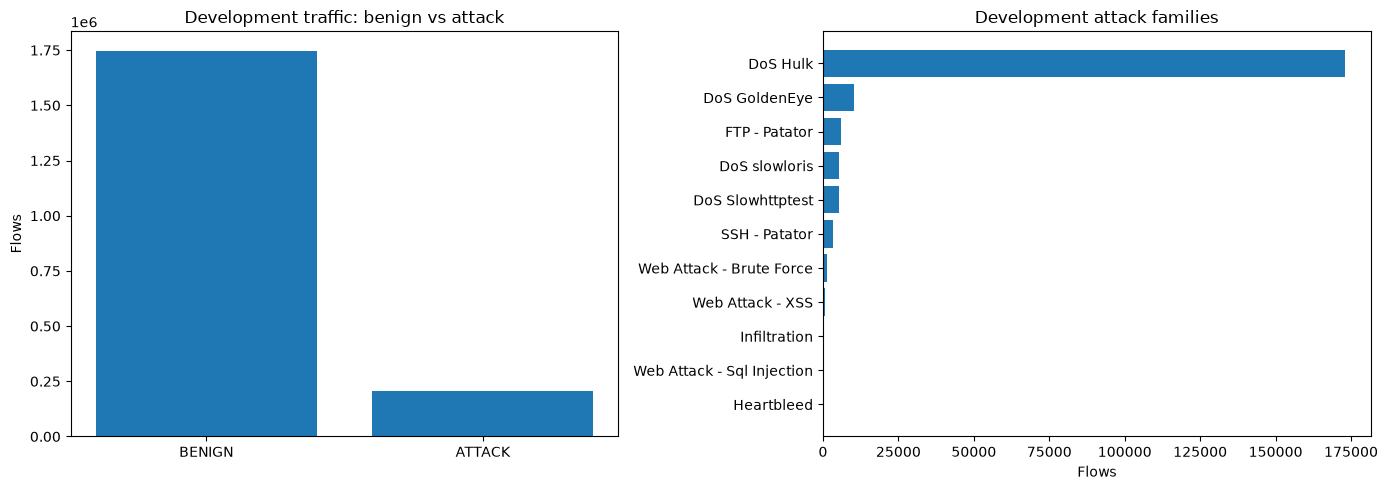

Development attack rate: 10.50%

Friday labels:
Label
BENIGN      414322
PortScan    158930
DDoS        128027
Bot           1966
Name: count, dtype: int64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = dev["y"].value_counts().sort_index()
axes[0].bar(["BENIGN", "ATTACK"], [class_counts.get(0, 0), class_counts.get(1, 0)])
axes[0].set_title("Development traffic: benign vs attack")
axes[0].set_ylabel("Flows")

attack_counts = dev.loc[dev.y == 1, "AttackType"].value_counts().sort_values(ascending=True)
axes[1].barh(attack_counts.index, attack_counts.values)
axes[1].set_title("Development attack families")
axes[1].set_xlabel("Flows")

plt.tight_layout()
plt.show()

print("Development attack rate:", f"{100 * dev.y.mean():.2f}%")
print("\nFriday labels:")
print(friday[LABEL_COL].value_counts())

## 6. Feature quality and distributions

Look at missing/infinite values and the scale of the numeric flow features before deciding what should enter the model.

Numeric feature count: 77


,NaN,Unique,Zero,Min,Median,Max
Flow Packets/s,1156,957055,0,-2000000.0,79.184589,4.000000e+06
Flow Bytes/s,1156,1230369,249500,-261000000.0,3329.218050,2.071000e+09
Destination Port,0,49505,1283,0.0,80.000000,6.553500e+04
Bwd Avg Bytes/Bulk,0,1,1952893,0.0,0.000000,0.000000e+00
Fwd Avg Packets/Bulk,0,1,1952893,0.0,0.000000,0.000000e+00
Fwd Avg Bytes/Bulk,0,1,1952893,0.0,0.000000,0.000000e+00
Avg Bwd Segment Size,0,129076,448312,0.0,92.000000,4.370687e+03
Avg Fwd Segment Size,0,88834,259422,0.0,39.000000,4.672000e+03
Average Packet Size,0,185740,249812,0.0,82.500000,3.893333e+03
Down/Up Ratio,0,29,716856,0.0,1.000000,1.560000e+02


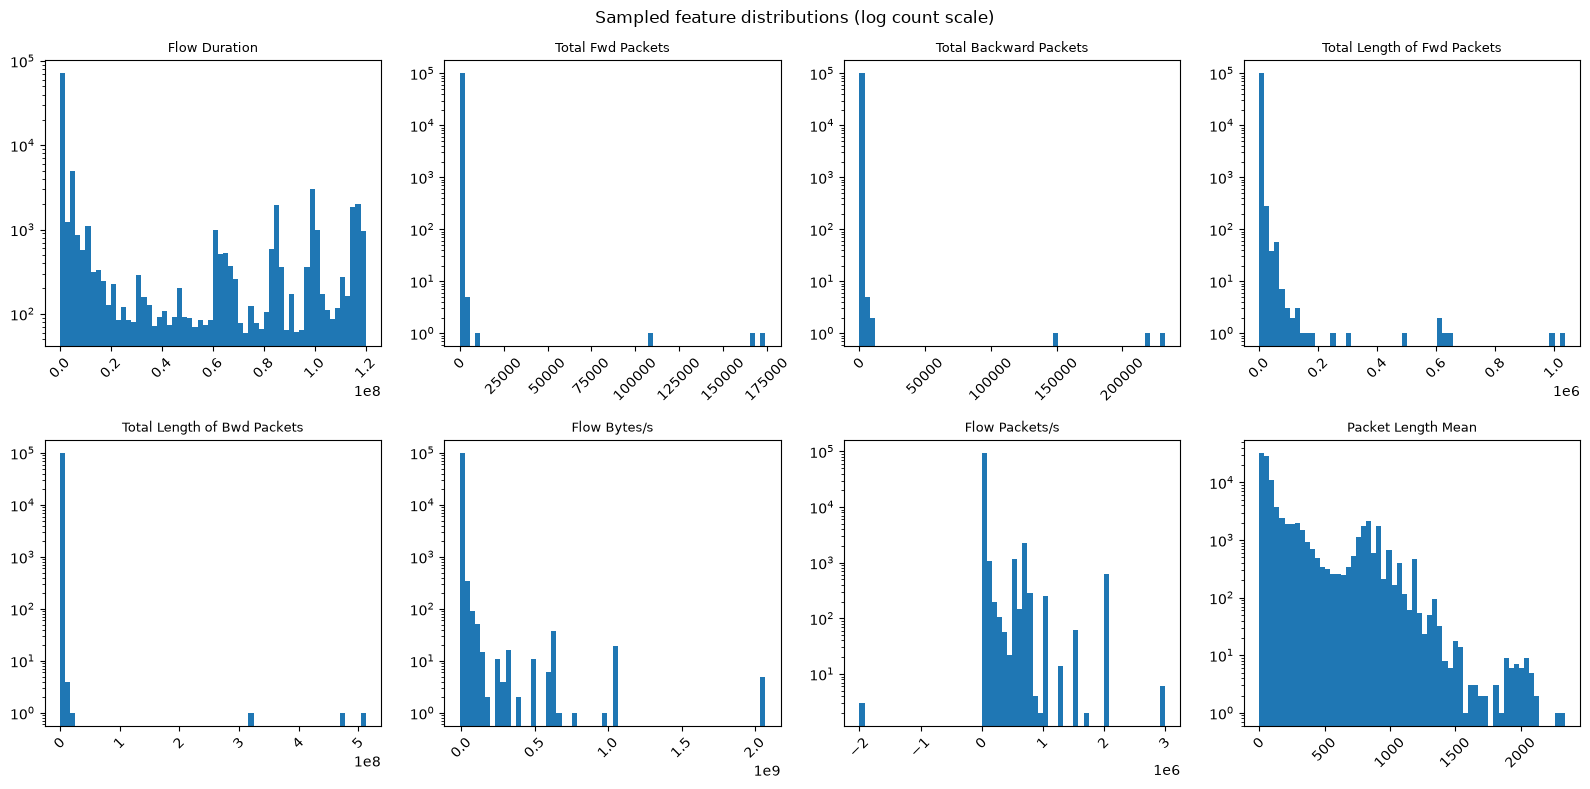

In [31]:
META_COLS = {LABEL_COL, "AttackType", "y", "SourceFile"}
raw_feature_cols = [c for c in dev.columns if c not in META_COLS and pd.api.types.is_numeric_dtype(dev[c])]

quality = pd.DataFrame({
    "NaN": dev[raw_feature_cols].isna().sum(),
    "Unique": dev[raw_feature_cols].nunique(dropna=True),
    "Zero": (dev[raw_feature_cols] == 0).sum(),
    "Min": dev[raw_feature_cols].min(),
    "Median": dev[raw_feature_cols].median(),
    "Max": dev[raw_feature_cols].max(),
})

print("Numeric feature count:", len(raw_feature_cols))
display(quality.sort_values("NaN", ascending=False).head(15))

# Show distributions for a few common flow-level quantities. Log scale helps with heavily skewed traffic features.
preferred = [
    c for c in [
        "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
        "Total Length of Fwd Packets", "Total Length of Bwd Packets",
        "Flow Bytes/s", "Flow Packets/s", "Packet Length Mean"
    ] if c in raw_feature_cols
]

sample_n = min(100_000, len(dev))
sample_df = dev.iloc[RNG.choice(len(dev), size=sample_n, replace=False)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), preferred):
    values = sample_df[col].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(values, bins=60)
    ax.set_title(col, fontsize=9)
    ax.set_yscale("log")
    ax.tick_params(axis="x", labelrotation=45)
for ax in axes.ravel()[len(preferred):]:
    ax.axis("off")
plt.suptitle("Sampled feature distributions (log count scale)")
plt.tight_layout()
plt.show()

## 7. Feature correlation

The CICIDS2017 flow table contains many related measurements. A correlation view helps identify features that carry almost the same information. This is used when deciding the final schema, rather than taking every column.

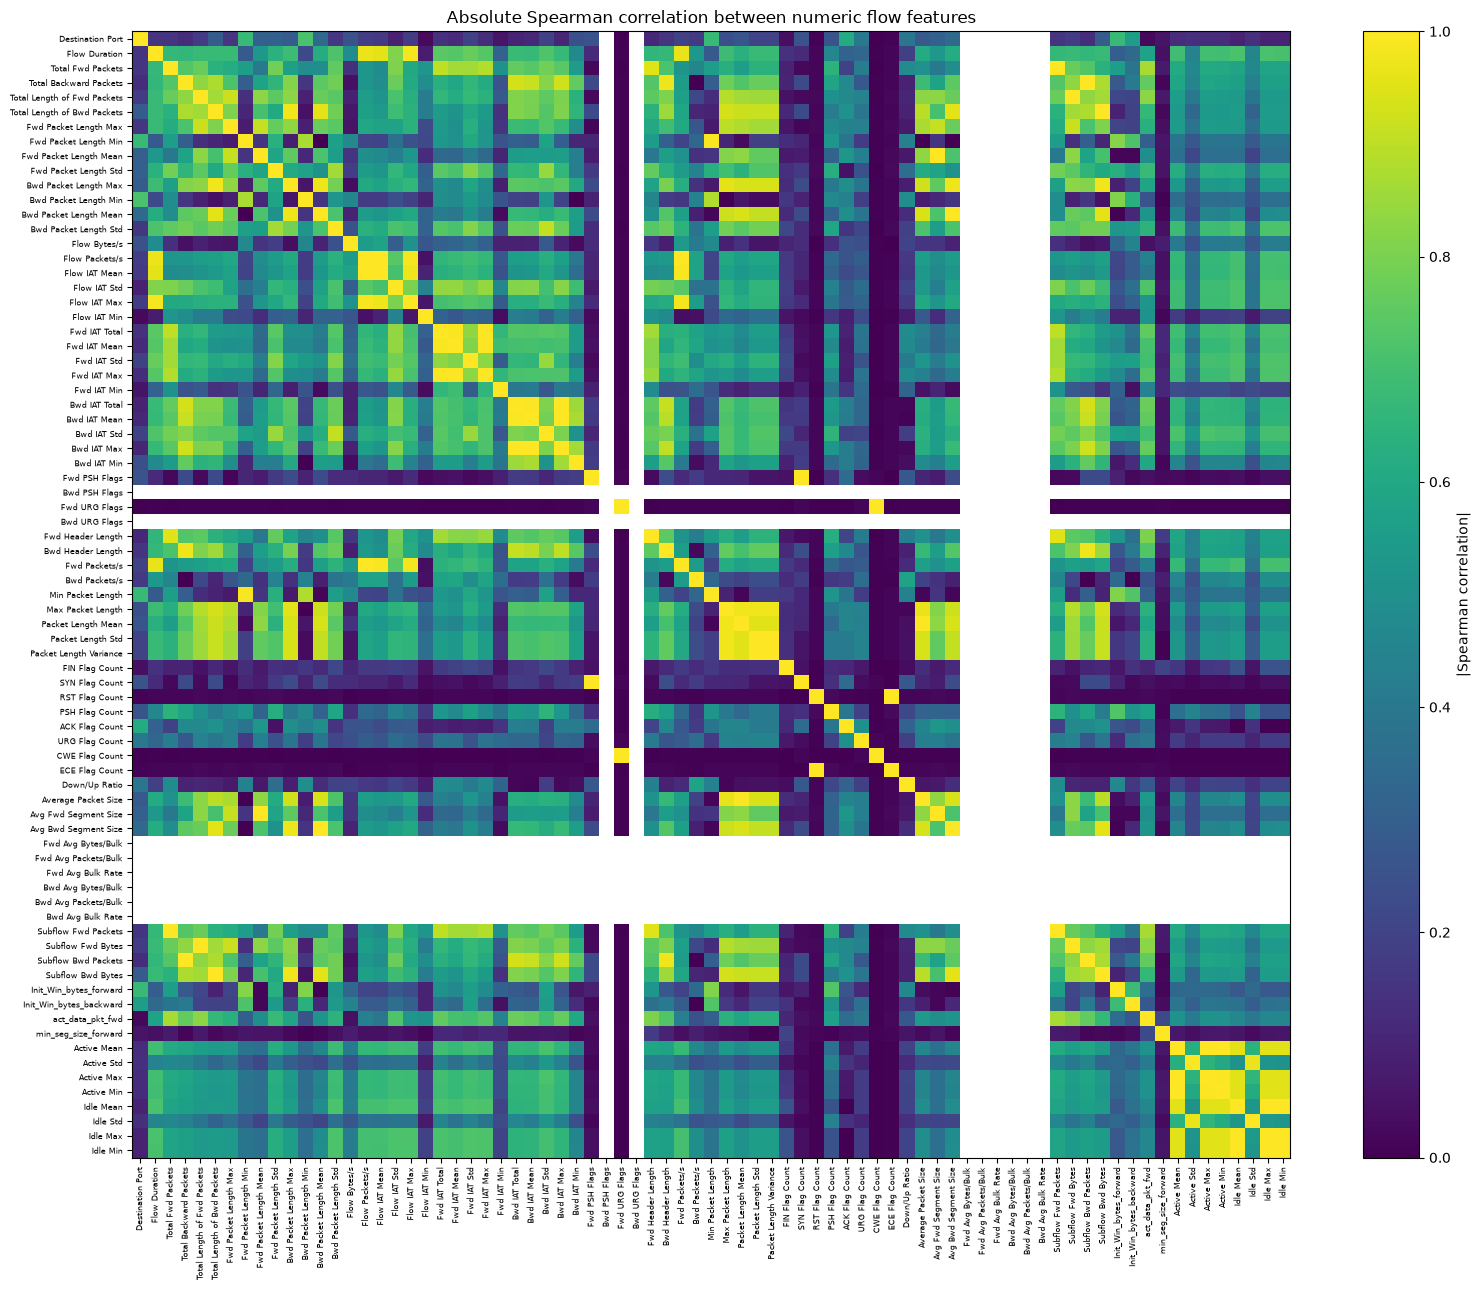

Highly correlated pairs (|rho| >= 0.99): 25


,Feature 1,Feature 2,|rho|
0,Total Fwd Packets,Subflow Fwd Packets,1.0000
14,Fwd PSH Flags,SYN Flag Count,1.0000
2,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000
3,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000
5,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000
6,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000
18,RST Flag Count,ECE Flag Count,1.0000
15,Fwd URG Flags,CWE Flag Count,1.0000
1,Total Backward Packets,Subflow Bwd Packets,1.0000
17,Packet Length Std,Packet Length Variance,1.0000


In [32]:
corr_sample_n = min(100_000, len(dev))
corr_idx = RNG.choice(len(dev), size=corr_sample_n, replace=False)
corr_sample = dev.iloc[corr_idx][raw_feature_cols]

spearman_corr = corr_sample.corr(method="spearman")

plt.figure(figsize=(16, 13))
plt.imshow(spearman_corr.abs(), aspect="auto", interpolation="nearest", vmin=0, vmax=1)
plt.colorbar(label="|Spearman correlation|")
plt.xticks(range(len(raw_feature_cols)), raw_feature_cols, rotation=90, fontsize=6)
plt.yticks(range(len(raw_feature_cols)), raw_feature_cols, fontsize=6)
plt.title("Absolute Spearman correlation between numeric flow features")
plt.tight_layout()
plt.show()

# Print the strongest feature pairs so the graph can be tied to a concrete schema decision.
pairs = []
for i, c1 in enumerate(raw_feature_cols):
    for c2 in raw_feature_cols[i + 1:]:
        r = abs(float(spearman_corr.loc[c1, c2]))
        if r >= 0.99:
            pairs.append((c1, c2, r))

high_corr_pairs = pd.DataFrame(pairs, columns=["Feature 1", "Feature 2", "|rho|"]).sort_values("|rho|", ascending=False)
print("Highly correlated pairs (|rho| >= 0.99):", len(high_corr_pairs))
display(high_corr_pairs.head(30).round(4))

## 8. Decide the V1 feature schema

The schema is now chosen from the dataset analysis:

1. Keep numeric flow features shared by development and Friday.
2. Remove constant features because they contain no useful variation.
3. Remove exact duplicate feature columns.
4. From the correlation analysis above, remove one feature from pairs with `|Spearman rho| > 0.99`.

This keeps the feature set compact while preserving the main flow measurements. The correlation pruning uses development data only.

In [33]:
feature_cols = [c for c in raw_feature_cols if c in friday.columns]

constant_features = [c for c in feature_cols if dev[c].nunique(dropna=True) <= 1]

exact_duplicate_features = []
seen_hashes = {}
for c in feature_cols:
    h = pd.util.hash_pandas_object(dev[c], index=False).sum()
    if h in seen_hashes and dev[c].equals(dev[seen_hashes[h]]):
        exact_duplicate_features.append(c)
    else:
        seen_hashes[h] = c

feature_cols = [c for c in feature_cols if c not in constant_features and c not in exact_duplicate_features]

# Recompute the correlation matrix after removing exact duplicates.
work_corr = dev.iloc[corr_idx][feature_cols].corr(method="spearman").abs()
redundant_features = set()
for i, c1 in enumerate(feature_cols):
    if c1 in redundant_features:
        continue
    for c2 in feature_cols[i + 1:]:
        if c2 in redundant_features:
            continue
        if work_corr.loc[c1, c2] > 0.99:
            redundant_features.add(c2)

FEATURE_SCHEMA = [c for c in feature_cols if c not in redundant_features]

print("Initial numeric features:", len(raw_feature_cols))
print("Constant features removed:", len(constant_features))
print("Exact duplicate features removed:", len(exact_duplicate_features))
print("Highly correlated features removed:", len(redundant_features))
print("Final feature count:", len(FEATURE_SCHEMA))
print("\nFEATURE_SCHEMA:")
print(FEATURE_SCHEMA)

assert all(c in friday.columns for c in FEATURE_SCHEMA)
assert len(FEATURE_SCHEMA) == len(set(FEATURE_SCHEMA))

Initial numeric features: 77
Constant features removed: 8
Exact duplicate features removed: 11
Highly correlated features removed: 17
Final feature count: 48

FEATURE_SCHEMA:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Init_Win_bytes_forw

## 9. Train / validation split for the unseen-family model

Friday remains completely closed. Monday–Thursday are split into a training pool and validation set. The benign class is capped in the training pool to keep Random Forest training practical on the available hardware; all attack rows in the selected training pool are retained.

In [34]:
VAL_FRACTION = 0.25
N_BENIGN_TRAIN = 450_000

idx = np.arange(len(dev))
idx_train_pool, idx_val = train_test_split(
    idx, test_size=VAL_FRACTION, stratify=dev["y"], random_state=RANDOM_STATE
)

pool_benign = idx_train_pool[dev.y.to_numpy()[idx_train_pool] == 0]
pool_attack = idx_train_pool[dev.y.to_numpy()[idx_train_pool] == 1]

if len(pool_benign) > N_BENIGN_TRAIN:
    sampled_benign = RNG.choice(pool_benign, size=N_BENIGN_TRAIN, replace=False)
else:
    sampled_benign = pool_benign

idx_train = np.sort(np.concatenate([sampled_benign, pool_attack]))
train_df = dev.iloc[idx_train].copy()
val_df = dev.iloc[idx_val].copy()

X_train = train_df[FEATURE_SCHEMA]
y_train = train_df.y.to_numpy()
X_val = val_df[FEATURE_SCHEMA]
y_val = val_df.y.to_numpy()

print(f"TRAIN      : {len(train_df):,}")
print(f"VALIDATION : {len(val_df):,}")
print(f"BENIGN training cap: {N_BENIGN_TRAIN:,}")
print("\nTraining attack families:")
print(train_df.loc[train_df.y == 1, "AttackType"].value_counts())

TRAIN      : 603,817
VALIDATION : 488,224
BENIGN training cap: 450,000

Training attack families:
AttackType
DoS Hulk                      129533
DoS GoldenEye                   7765
FTP - Patator                   4480
DoS slowloris                   4070
DoS Slowhttptest                3894
SSH - Patator                   2429
Web Attack - Brute Force        1095
Web Attack - XSS                 499
Infiltration                      26
Web Attack - Sql Injection        17
Heartbleed                         9
Name: count, dtype: int64


## 10. Shared flow-feature cleaning

The same feature schema and preprocessing are used for every Random Forest model. Missing values are learned from the training data only.

In [35]:
class FlowFeatureCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, feature_schema):
        self.feature_schema = list(feature_schema)

    def _matrix(self, X):
        if isinstance(X, dict):
            X = pd.DataFrame([X])
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_schema)
        missing = [c for c in self.feature_schema if c not in X.columns]
        if missing:
            raise ValueError(f"Missing required features: {missing}")
        return X[self.feature_schema].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)

    def fit(self, X, y=None):
        M = self._matrix(X)
        finite = np.where(np.isfinite(M), M, np.nan)
        with np.errstate(all="ignore"):
            self.median_ = np.nanmedian(finite, axis=0)
            self.max_ = np.nanmax(finite, axis=0)
            self.min_ = np.nanmin(finite, axis=0)
        self.median_ = np.nan_to_num(self.median_, nan=0.0).astype(np.float32)
        self.max_ = np.nan_to_num(self.max_, nan=0.0).astype(np.float32)
        self.min_ = np.nan_to_num(self.min_, nan=0.0).astype(np.float32)
        return self

    def transform(self, X):
        M = self._matrix(X)
        M = np.where(np.isposinf(M), self.max_, M)
        M = np.where(np.isneginf(M), self.min_, M)
        M = np.where(np.isnan(M), self.median_, M)
        return np.ascontiguousarray(M, dtype=np.float32)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_schema, dtype=object)

def make_rf():
    return Pipeline([
        ("cleaner", FlowFeatureCleaner(FEATURE_SCHEMA)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            criterion="gini",
            max_features="sqrt",
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

## 11. Train the unseen-family Random Forest

In [36]:
from sklearn.pipeline import Pipeline
unseen_model = make_rf()
t0 = time.time()
unseen_model.fit(X_train, y_train)
print(f"Random Forest trained in {time.time() - t0:.1f}s")

Random Forest trained in 22.1s


## 12. Evaluation helper

In [37]:
def evaluate_model(model, X, y, threshold=0.5, name="model", plot=True):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    result = {
        "model": name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "FPR": fp / max(fp + tn, 1),
    }
    print(f"\n===== {name} =====")
    for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "FPR"]:
        print(f"{k:>10}: {result[k]:.5f}")
    print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print("\nClassification report:")
    print(classification_report(y, pred, target_names=["BENIGN", "ATTACK"], digits=4, zero_division=0))
    if plot:
        ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=["BENIGN", "ATTACK"], values_format="d")
        plt.title(name)
        plt.tight_layout()
        plt.show()
    return result, proba

## 13. Validation evaluation and threshold selection

The validation set is used only to choose the operating threshold. Friday is still untouched.


===== Unseen-family model — Validation =====
  accuracy: 0.99964
 precision: 0.99749
    recall: 0.99904
        f1: 0.99827
   roc_auc: 0.99999
    pr_auc: 0.99979
       FPR: 0.00030
TN=436,822  FP=129  FN=49  TP=51,224

Classification report:
              precision    recall  f1-score   support

      BENIGN     0.9999    0.9997    0.9998    436951
      ATTACK     0.9975    0.9990    0.9983     51273

    accuracy                         0.9996    488224
   macro avg     0.9987    0.9994    0.9990    488224
weighted avg     0.9996    0.9996    0.9996    488224



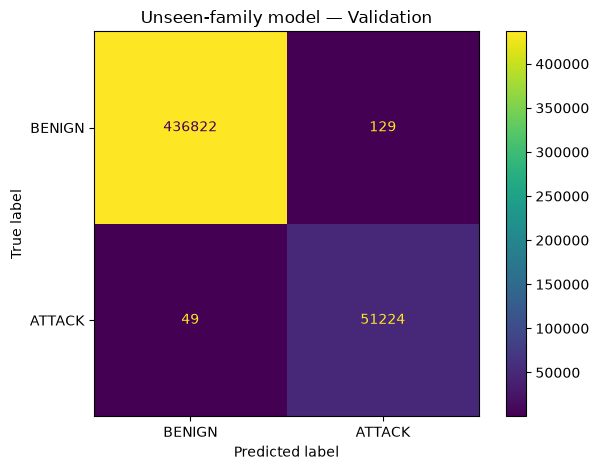

Selected threshold: 0.5150
Validation precision: 0.99764
Validation recall:    0.99902
Validation F1:        0.99833


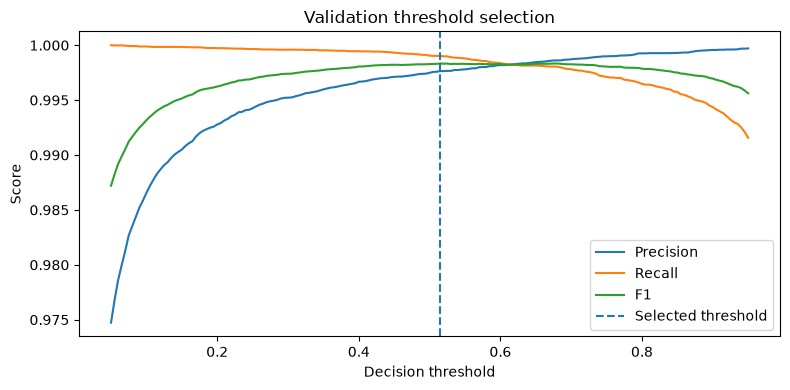

In [38]:
val_default_result, p_val = evaluate_model(
    unseen_model, X_val, y_val, threshold=0.50, name="Unseen-family model — Validation"
)

thresholds = np.linspace(0.05, 0.95, 181)
threshold_rows = []
for t in thresholds:
    pred = (p_val >= t).astype(np.int8)
    threshold_rows.append({
        "threshold": t,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    })
threshold_table = pd.DataFrame(threshold_rows)
best_row = threshold_table.loc[threshold_table.f1.idxmax()]
FINAL_THRESHOLD = float(best_row.threshold)

print(f"Selected threshold: {FINAL_THRESHOLD:.4f}")
print(f"Validation precision: {best_row.precision:.5f}")
print(f"Validation recall:    {best_row.recall:.5f}")
print(f"Validation F1:        {best_row.f1:.5f}")

plt.figure(figsize=(8, 4))
plt.plot(threshold_table.threshold, threshold_table.precision, label="Precision")
plt.plot(threshold_table.threshold, threshold_table.recall, label="Recall")
plt.plot(threshold_table.threshold, threshold_table.f1, label="F1")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label="Selected threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Validation threshold selection")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Lock the unseen-family model

From this point onward, the model and threshold are fixed. Friday is now used once as the genuine held-out evaluation for the unseen-family experiment.

In [39]:
UNSEEN_MODEL = unseen_model
FINAL_FEATURES = FEATURE_SCHEMA

print("Unseen-family configuration locked.")
print("Features:", len(FINAL_FEATURES))
print("Threshold:", FINAL_THRESHOLD)

Unseen-family configuration locked.
Features: 48
Threshold: 0.5149999999999999


## 15. Final Friday evaluation — unseen-family model


===== Unseen-family model — Friday held-out test =====
  accuracy: 0.62040
 precision: 0.99451
    recall: 0.07646
        f1: 0.14200
   roc_auc: 0.70886
    pr_auc: 0.67030
       FPR: 0.00029
TN=414,200  FP=122  FN=266,832  TP=22,091

Classification report:
              precision    recall  f1-score   support

      BENIGN     0.6082    0.9997    0.7563    414322
      ATTACK     0.9945    0.0765    0.1420    288923

    accuracy                         0.6204    703245
   macro avg     0.8014    0.5381    0.4491    703245
weighted avg     0.7669    0.6204    0.5039    703245



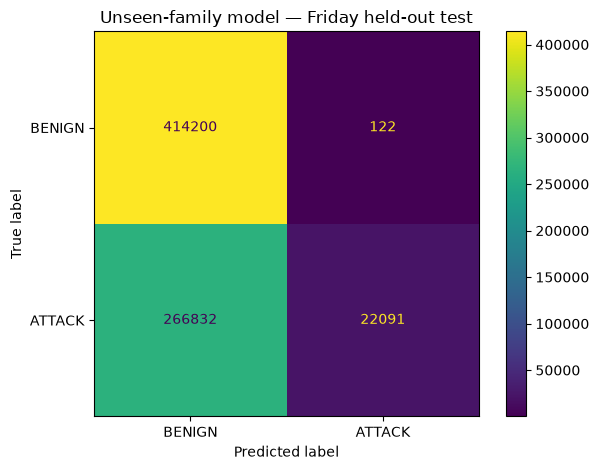

In [40]:
X_friday = friday[FINAL_FEATURES]
y_friday = friday.y.to_numpy()

unseen_friday_result, p_friday_unseen = evaluate_model(
    UNSEEN_MODEL, X_friday, y_friday, threshold=FINAL_THRESHOLD,
    name="Unseen-family model — Friday held-out test"
)

pred_friday_unseen = (p_friday_unseen >= FINAL_THRESHOLD).astype(np.int8)

## 16. Per-attack-family evaluation of the unseen-family model

In [41]:
train_families = set(train_df.loc[train_df.y == 1, "AttackType"].unique())
family_data = friday[["AttackType", "y"]].copy()
family_data["probability"] = p_friday_unseen
family_data["predicted"] = pred_friday_unseen

rows = []
for label, group in family_data.groupby("AttackType"):
    attack = label != "BENIGN"
    rows.append({
        "AttackType": label,
        "Flows": len(group),
        "Seen_in_training": ("n/a" if not attack else label in train_families),
        "Detected": (int(group.predicted.sum()) if attack else np.nan),
        "Detection_rate": (float(group.predicted.mean()) if attack else np.nan),
        "Missed": (int((group.predicted == 0).sum()) if attack else np.nan),
        "False_alarm_rate": (float(group.predicted.mean()) if not attack else np.nan),
        "Median_P_attack": float(group.probability.median()),
    })
family_results = pd.DataFrame(rows).sort_values("Flows", ascending=False)
display(family_results.round(4))

print("\nFriday attack families unseen during training:")
print(sorted(set(friday.loc[friday.y == 1, "AttackType"]) - train_families))

,AttackType,Flows,Seen_in_training,Detected,Detection_rate,Missed,False_alarm_rate,Median_P_attack
0,BENIGN,414322,n/a,NaN,NaN,NaN,0.0003,0.000
3,PortScan,158930,False,152.0,0.0010,158778.0,NaN,0.000
2,DDoS,128027,False,21939.0,0.1714,106088.0,NaN,0.425
1,Bot,1966,False,0.0,0.0000,1966.0,NaN,0.000



Friday attack families unseen during training:
['Bot', 'DDoS', 'PortScan']


## 17. Error analysis — unseen-family model

In [42]:
false_positives = family_data[(family_data.y == 0) & (family_data.predicted == 1)]
false_negatives = family_data[(family_data.y == 1) & (family_data.predicted == 0)]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))
print("\nMissed attacks by family:")
display(false_negatives["AttackType"].value_counts().rename("Missed flows").to_frame())

False positives: 122
False negatives: 266832

Missed attacks by family:


,Missed flows
AttackType,
PortScan,158778
DDoS,106088
Bot,1966


## 18. Train the second Random Forest with Friday included

train a second model using Monday–Thursday **plus Friday**.

the benign class is capped again while all attack rows from the combined data are retained. This model is saved separately from the unseen-family model.

In [43]:
full_data = pd.concat([dev, friday], ignore_index=True)

full_attack_idx = np.flatnonzero(full_data.y.to_numpy() == 1)
full_benign_idx = np.flatnonzero(full_data.y.to_numpy() == 0)

if len(full_benign_idx) > N_BENIGN_TRAIN:
    full_benign_sample = RNG.choice(full_benign_idx, size=N_BENIGN_TRAIN, replace=False)
else:
    full_benign_sample = full_benign_idx

full_train_idx = np.sort(np.concatenate([full_benign_sample, full_attack_idx]))
full_train_df = full_data.iloc[full_train_idx].copy()
X_full_train = full_train_df[FINAL_FEATURES]
y_full_train = full_train_df.y.to_numpy()

print("Combined development + Friday rows:", f"{len(full_data):,}")
print("Rows used for full model training:", f"{len(full_train_df):,}")
print("Attack rows used:", f"{int((y_full_train == 1).sum()):,}")

full_model = make_rf()
t0 = time.time()
full_model.fit(X_full_train, y_full_train)
print(f"Full-data Random Forest trained in {time.time() - t0:.1f}s")

Combined development + Friday rows: 2,656,138
Rows used for full model training: 944,013
Attack rows used: 494,013
Full-data Random Forest trained in 35.3s


## 19. Evaluate the Friday-included model on Friday

This is intentionally labeled **training-inclusive**. It answers: *what does the model look like after it has been allowed to learn from Friday?* It must not be presented as a held-out generalization score.


===== Full-data model — Friday training-inclusive evaluation =====
  accuracy: 0.99904
 precision: 0.99768
    recall: 0.99999
        f1: 0.99883
   roc_auc: 0.99999
    pr_auc: 0.99997
       FPR: 0.00162
TN=413,650  FP=672  FN=4  TP=288,919

Classification report:
              precision    recall  f1-score   support

      BENIGN     1.0000    0.9984    0.9992    414322
      ATTACK     0.9977    1.0000    0.9988    288923

    accuracy                         0.9990    703245
   macro avg     0.9988    0.9992    0.9990    703245
weighted avg     0.9990    0.9990    0.9990    703245



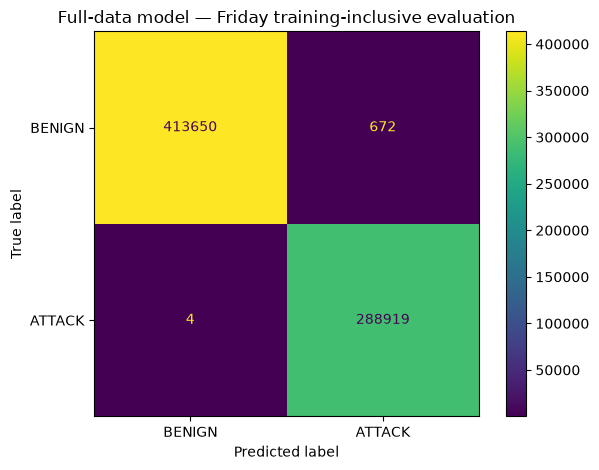

In [44]:
full_friday_result, p_friday_full = evaluate_model(
    full_model, X_friday, y_friday, threshold=FINAL_THRESHOLD,
    name="Full-data model — Friday training-inclusive evaluation"
)
pred_friday_full = (p_friday_full >= FINAL_THRESHOLD).astype(np.int8)

## 20. Compare the two models on Friday

The threshold is kept identical so the comparison is about the effect of adding Friday to training.

**Important:** the first row is a true held-out Friday evaluation; the second row has seen Friday during training, so its metrics are expected to be easier to achieve and are not directly comparable as a generalization benchmark.

,Evaluation,model,precision,recall,f1,roc_auc,pr_auc,FPR,accuracy
0,Friday held-out,Unseen-family model — Friday held-out test,0.9945,0.0765,0.1420,0.7089,0.6703,0.0003,0.6204
1,Friday training-inclusive,Full-data model — Friday training-inclusive ev...,0.9977,1.0000,0.9988,1.0000,1.0000,0.0016,0.9990


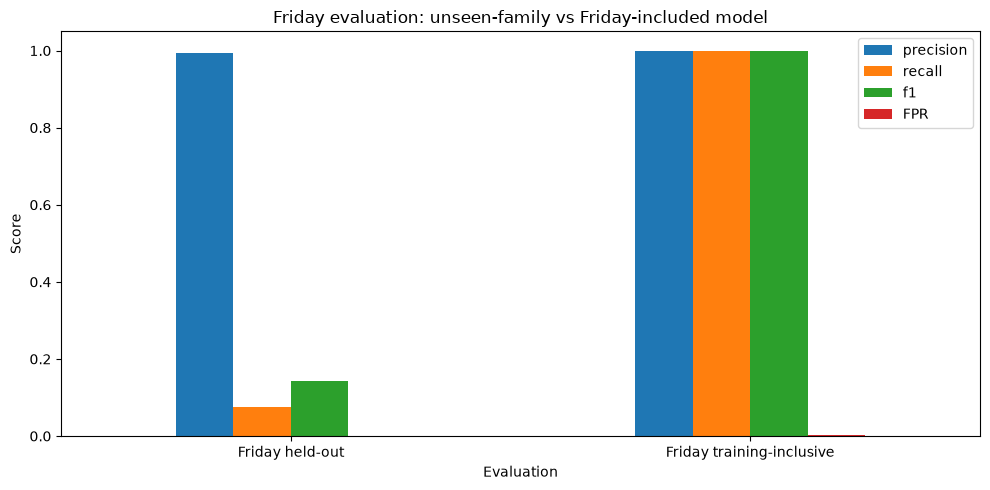

In [45]:
comparison = pd.DataFrame([
    {**unseen_friday_result, "Evaluation": "Friday held-out"},
    {**full_friday_result, "Evaluation": "Friday training-inclusive"},
])
comparison = comparison[[
    "Evaluation", "model", "precision", "recall", "f1", "roc_auc", "pr_auc", "FPR", "accuracy"
]]
display(comparison.round(4))

metric_plot = comparison.set_index("Evaluation")[["precision", "recall", "f1", "FPR"]]
metric_plot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Score")
plt.title("Friday evaluation: unseen-family vs Friday-included model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 21. Random Forest feature importance

Feature importance is shown for the unseen-family model because that is the model used for the actual held-out experiment.

,Importance
Bwd Packet Length Std,0.097262
Max Packet Length,0.085066
Bwd Packet Length Mean,0.073297
Packet Length Std,0.070853
Bwd Packet Length Max,0.066557
Destination Port,0.061868
Packet Length Mean,0.052057
Total Length of Bwd Packets,0.051006
Flow Packets/s,0.049703
Flow IAT Max,0.046463


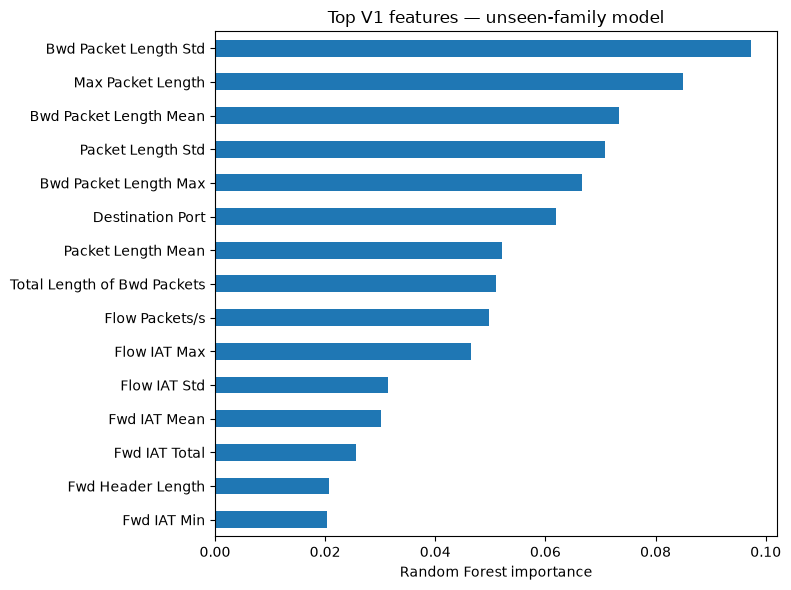

In [46]:
rf_classifier = UNSEEN_MODEL.named_steps["model"]
importance = pd.Series(rf_classifier.feature_importances_, index=FINAL_FEATURES).sort_values(ascending=False)
display(importance.head(20).to_frame("Importance"))

plt.figure(figsize=(8, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Random Forest importance")
plt.title("Top V1 features — unseen-family model")
plt.tight_layout()
plt.show()

## 22. Save both detection engines

Two artifacts are intentionally kept separate:

- `ids_v1_unseen_family_pipeline.joblib` — Monday–Thursday trained model used for the held-out Friday experiment.
- `ids_v1_full_data_pipeline.joblib` — model retrained after adding Friday to the training data.

The same feature schema and decision threshold are recorded for reproducibility.

In [47]:
UNSEEN_PIPELINE_PATH = ARTIFACT_DIR / "ids_v1_unseen_family_pipeline.joblib"
FULL_PIPELINE_PATH = ARTIFACT_DIR / "ids_v1_full_data_pipeline.joblib"
SCHEMA_PATH = ARTIFACT_DIR / "ids_v1_feature_schema.json"
META_PATH = ARTIFACT_DIR / "ids_v1_metadata.json"

joblib.dump(UNSEEN_MODEL, UNSEEN_PIPELINE_PATH, compress=3)
joblib.dump(full_model, FULL_PIPELINE_PATH, compress=3)

with open(SCHEMA_PATH, "w") as f:
    json.dump({"feature_schema": FINAL_FEATURES, "n_features": len(FINAL_FEATURES)}, f, indent=2)

metadata = {
    "version": "V1",
    "dataset": "CICIDS2017 MachineLearningCVE",
    "task": "binary flow classification",
    "development_files": DEV_FILES,
    "final_test_files": TEST_FILES,
    "n_features": len(FINAL_FEATURES),
    "model": "RandomForestClassifier",
    "n_estimators": 200,
    "random_state": RANDOM_STATE,
    "decision_threshold": FINAL_THRESHOLD,
    "unseen_family_model": {
        "training": "Monday–Thursday",
        "training_rows": len(train_df),
        "validation_rows": len(val_df),
        "friday_metrics": {k: float(v) for k, v in unseen_friday_result.items() if isinstance(v, (int, float, np.integer, np.floating))},
        "artifact": str(UNSEEN_PIPELINE_PATH),
    },
    "full_data_model": {
        "training": "Monday–Thursday + Friday",
        "training_rows": len(full_train_df),
        "friday_training_inclusive_metrics": {k: float(v) for k, v in full_friday_result.items() if isinstance(v, (int, float, np.integer, np.floating))},
        "artifact": str(FULL_PIPELINE_PATH),
        "evaluation_note": "Friday is included in training; these metrics are not a held-out generalization estimate.",
    },
}
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for path in [UNSEEN_PIPELINE_PATH, FULL_PIPELINE_PATH, SCHEMA_PATH, META_PATH]:
    print(" ", path.resolve(), f"({path.stat().st_size / 1e6:.2f} MB)")

Saved:
  /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/artifacts/ids_v1_unseen_family_pipeline.joblib (8.16 MB)
  /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/artifacts/ids_v1_full_data_pipeline.joblib (18.62 MB)
  /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/artifacts/ids_v1_feature_schema.json (0.00 MB)
  /Users/Shreyas/Library/CloudStorage/OneDrive-Personal/Documents/IDSS/artifacts/ids_v1_metadata.json (0.00 MB)


## 23. Reload test for both saved models

In [48]:
loaded_unseen = joblib.load(UNSEEN_PIPELINE_PATH)
loaded_full = joblib.load(FULL_PIPELINE_PATH)

sample_flow = friday[FINAL_FEATURES].iloc[[0]]
p_unseen = loaded_unseen.predict_proba(sample_flow)[:, 1][0]
p_full = loaded_full.predict_proba(sample_flow)[:, 1][0]

print("Sample flow")
print("-----------")
print("Original dataset label:", friday["AttackType"].iloc[0])
print("Unseen-family model P(attack):", round(float(p_unseen), 5))
print("Full-data model P(attack):", round(float(p_full), 5))
print("Unseen-family prediction:", "ATTACK" if p_unseen >= FINAL_THRESHOLD else "BENIGN")
print("Full-data prediction:", "ATTACK" if p_full >= FINAL_THRESHOLD else "BENIGN")

Sample flow
-----------
Original dataset label: BENIGN
Unseen-family model P(attack): 0.0
Full-data model P(attack): 0.0
Unseen-family prediction: BENIGN
Full-data prediction: BENIGN


# V1 Summary

The completed V1 is an **offline flow-level binary intrusion detector using Random Forest only**.

### Workflow

- Audit and clean CICIDS2017
- Explore class balance, feature distributions, and feature correlations
- Decide a practical feature schema from that analysis
- Train an **unseen-family Random Forest** on Monday–Thursday
- Select the decision threshold using Monday–Thursday validation data
- Evaluate that locked model on untouched Friday traffic
- Analyze errors and attack-family detection
- Retrain a **separate full-data Random Forest** after adding Friday
- Evaluate the full-data model on Friday as a clearly labeled training-inclusive reference
- Compare both models in the final section
- Save both pipelines separately

The held-out Friday result is the important generalization experiment. The Friday-included result is useful for understanding the effect of additional training data, but it is not a held-out test result.